In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Fri Sep  8 14:54:33 2023

@author: Skarleth Motino Flores
Institution: USRA-NASA

"""

# ------------------------------------------------------
#
#
#                      Libraries 
#
#
# ------------------------------------------------------

import os
import time 

from tqdm import tqdm 
from scipy.interpolate import RegularGridInterpolator
from math import log10, log1p
from matplotlib import cm

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
np.set_printoptions(precision=4)

import warnings
warnings.filterwarnings('ignore')


# ------------------------------------------------------
#
#                   Functions
#
# ------------------------------------------------------

from gism_Functions import *

# ------------------------------------------------------
#
#               Constants
#
# ------------------------------------------------------

c    = 3e8    # m/s
Lsun = 3.826e26													# Watts
pi   = 3.1416 


In [8]:
pwd

'/Users/admin/Scripts/GalaxyISM_0914'

In [9]:
# Models Line Ratio: ### Order of Lines of the Models Cube
#1 - 'OIII52_OIII88', 
#2 - 'OIII52_NIII57', 
#3 - 'OIII88_NIII57', 
#4 - 'OIII52_NII122',  
#5 - 'OIII88_NII122', 
#6 - '(2.2XOIII88+OIII52)/NIII57'
#7 - 'NIII57/NII122'
# Best models: [1,0,0,0,0,1,0]


In [10]:
# ------------------------------------------------------
#
#              Read Models
#
#
# ------------------------------------------------------
#

 
#path = '/Users/smotinof/Documents/Scripts/GalaxyISM/' 
path = '/Users/admin/Scripts/GalaxyISM_0914/' 

# Line fluxes in Jykm/s  
  
nameFile_Models = path+'input/PereiraModelsSB.txt' 
Models = ReadModels(nameFile_Models)
print (Models.columns)
Models


Index(['Z/Zo', 'log(n_Hcm-3)', 'log(U)', 'SIII19_SIII33', 'OIII52_OIII88',
       'NII122_NII205', 'SIV11_NeII16', 'NeII13_NeIII16', 'OIII52_NIII57',
       'OIII88_NIII57', 'OIII52_NII122', 'OIII52_NII205', 'OIII88_NII122',
       'OIII88_NII205', '(2.2XOIII88+OIII52)/NIII57', 'NIII57_NII122', 'U',
       'NIII57_OIII88', 'NII122_OIII88'],
      dtype='object')


,Z/Zo,log(n_Hcm-3),log(U),SIII19_SIII33,OIII52_OIII88,NII122_NII205,SIV11_NeII16,NeII13_NeIII16,OIII52_NIII57,OIII88_NIII57,OIII52_NII122,OIII52_NII205,OIII88_NII122,OIII88_NII205,(2.2XOIII88+OIII52)/NIII57,NIII57_NII122,U,NIII57_OIII88,NII122_OIII88
0,0.05,1,-4.0,0.436516,0.588844,0.912011,0.003236,1.995262,9.332543,15.848932,1.258925,1.148154,2.137962,1.949845,44.200193,0.134896,0.0001,0.063096,0.467735
1,0.05,1,-3.5,0.446684,0.588844,0.912011,0.021878,0.645654,10.0,16.982437,11.220185,10.23293,19.054607,17.378008,47.36136,1.122018,0.000316,0.058884,0.052481
2,0.05,1,-3.0,0.457088,0.588844,0.933254,0.112202,0.204174,11.748976,19.952623,75.857758,69.183097,128.824955,117.489755,55.644746,6.456542,0.001,0.050119,0.007762
3,0.05,1,-2.5,0.467735,0.588844,0.954993,0.436516,0.064565,13.182567,22.387211,316.227766,301.995172,537.031796,501.187234,62.434432,23.988329,0.003162,0.044668,0.001862
4,0.05,1,-2.0,0.47863,0.588844,0.977237,1.230269,0.020417,14.791084,25.118864,1023.292992,1000.0,1737.800829,1659.586907,70.052585,69.183097,0.01,0.039811,0.000575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,2.00,6,-4.0,11.481536,10.23293,9.772372,0.000708,128.824955,1.148154,0.112202,0.054954,0.537032,0.00537,0.053703,1.394998,0.047863,0.0001,8.912509,186.208714
146,2.00,6,-3.5,11.748976,10.23293,9.772372,0.003631,52.480746,1.202264,0.11749,0.218776,2.137962,0.02138,0.20893,1.460742,0.18197,0.000316,8.51138,46.773514
147,2.00,6,-3.0,11.748976,10.23293,9.772372,0.012303,21.379621,1.348963,0.131826,1.148154,11.220185,0.112202,1.096478,1.638979,0.851138,0.001,7.585776,8.912509
148,2.00,6,-2.5,11.748976,10.23293,9.772372,0.029512,8.912509,1.737801,0.169824,5.128614,50.118723,0.501187,4.897788,2.111414,2.951209,0.003162,5.888437,1.995262


In [11]:
Models['log(U)'].min()

-4.0

In [18]:

date = '20240418'
#file1 = 'UNZ_He-2-10_a_20240314.txt'
#file2 = 'UNZ_Haro-03_a_20240314.txt'
#file3 = 'UNZ_Haro-10_a_20240314.txt'

file1 = 'UNZ_He2-10-b_20240418.txt'
file2 = 'UNZ_Haro-03-b_20240418.txt'
file3 = 'UNZ_Haro-10-b_20240418.txt'
file4 = 'UNZ_M82b_20240418.txt'


df_1 = pd.read_csv(file1,  header = 0, engine='python') 
df_2 = pd.read_csv(file2,  header = 0, engine='python') 
df_3 = pd.read_csv(file3,  header = 0, engine='python') 

df_1.columns

Index(['Galaxy', 'Flux_ID', 'u_bs', 'n_bs', 'z_bs', 'u_mn', 'u_unc', 'n_mn',
       'n_unc', 'z_mn', 'z_unc', 'u_50p', 'u_16p', 'u_84p', 'n_50p', 'n_16p',
       'n_84p', 'z_50p', 'z_16p', 'z_84p', 'LinesRatiosUsed'],
      dtype='object')

In [23]:
Tex_columns = [ 
'$\\frac{[OIII]52}{[OIII]88}$ , $\\frac{[NIII]57}{[OIII]88}$,   $\\frac{[OIII]52}{[OIII]88}$  ',  
'$\\frac{[NIII]57}{[NII]122}$ , $\\frac{(2.2X[OIII]88+[OIII]52)}{[NIII]57}$ ',
'$\\frac{[OIII]52}{[OIII]88}$ , $\\frac{[NIII]57}{[NII]122}$, $\\frac{(2.2X[OIII]88+[OIII]52)}{[NIII]57}$ '
]

In [24]:
#df_1

import pandas as pd

def csv_to_latex(input_csv_file, output_tex_file):
    # Read the CSV file
    df = pd.read_csv(input_csv_file)
    
    # Replace commas with ampersands
    
    
    df = df.applymap(lambda x: str(x).replace(',', '&'))
    
    
    df2=df[['Galaxy', 'u_mn', 'u_unc', 'n_mn', 'n_unc', 'z_mn', 'z_unc','LinesRatiosUsed']]
    df2['LinesRatiosUsed'] = Tex_columns
    
    # Convert the DataFrame to LaTeX format
    latex_table = df2.to_latex(index=False, escape=False)
    print(latex_table)
    # Write LaTeX table to a .tex file
    with open(output_tex_file, 'w') as f:
        f.write(latex_table)

        
        
        
# Example usage:

output_tex_file = 'H2-2-10-output-'+date+'.tex'
csv_to_latex(file1, output_tex_file)

output_tex_file = 'Haro03-output'+date+'.tex'
csv_to_latex(file2, output_tex_file)

output_tex_file = 'Haro10-output'+date+'.tex'
csv_to_latex(file3, output_tex_file)

output_tex_file = 'M-82-output'+date+'.tex'
csv_to_latex(file4, output_tex_file)



\begin{tabular}{llllllll}
\toprule
 Galaxy &   u_mn & u_unc &  n_mn & n_unc &  z_mn & z_unc &                                    LinesRatiosUsed \\
\midrule
He2-10- & -3.302 & 0.165 & 1.655 & 0.314 & 0.675 & 0.116 & $\frac{[OIII]52}{[OIII]88}$ , $\frac{[NIII]57}{... \\
He2-10- & -2.999 & 0.218 &  3.68 & 1.503 & 0.972 & 0.245 & $\frac{[NIII]57}{[NII]122}$ , $\frac{(2.2X[OIII... \\
He2-10- & -3.169 & 0.173 & 1.642 & 0.311 & 1.006 & 0.272 & $\frac{[OIII]52}{[OIII]88}$ , $\frac{[NIII]57}{... \\
\bottomrule
\end{tabular}

\begin{tabular}{llllllll}
\toprule
  Galaxy &   u_mn & u_unc &  n_mn & n_unc &  z_mn & z_unc &                                    LinesRatiosUsed \\
\midrule
Haro-03- & -3.192 & 0.143 &  1.44 & 0.283 & 0.302 &  0.08 & $\frac{[OIII]52}{[OIII]88}$ , $\frac{[NIII]57}{... \\
Haro-03- & -2.989 & 0.231 & 3.938 & 1.503 &  0.48 & 0.208 & $\frac{[NIII]57}{[NII]122}$ , $\frac{(2.2X[OIII... \\
Haro-03- & -3.082 & 0.141 & 1.429 & 0.282 & 0.459 & 0.223 & $\frac{[OIII]52}{[OIII]88}$ , $

In [16]:
df_1['LinesRatiosUsed'].values

array(['- OIII52/OIII88- NIII57/OIII88- NII122/OIII88',
       '- OIII52/OIII88- OIII88/NII122- OIII88/NIII57',
       '- OIII52/OIII88- (2.2OIII88+OIII52)/NIII57',
       '- OIII52/OIII88- NIII57/OIII88', '- OIII52/OIII88- NII122/OIII88',
       '- OIII52/OIII88- OIII88/NII122', '- NIII57/OIII88- NII122/OIII88',
       '- OIII88/NII122- OIII88/NIII57', '- NII122/OIII88- NIII57/NII122'],
      dtype=object)

In [17]:

column_list  = df_1['LinesRatiosUsed'].values
column_list

array(['- OIII52/OIII88- NIII57/OIII88- NII122/OIII88',
       '- OIII52/OIII88- OIII88/NII122- OIII88/NIII57',
       '- OIII52/OIII88- (2.2OIII88+OIII52)/NIII57',
       '- OIII52/OIII88- NIII57/OIII88', '- OIII52/OIII88- NII122/OIII88',
       '- OIII52/OIII88- OIII88/NII122', '- NIII57/OIII88- NII122/OIII88',
       '- OIII88/NII122- OIII88/NIII57', '- NII122/OIII88- NIII57/NII122'],
      dtype=object)

['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'gray', 'brown']
/Users/admin/Scripts/GalaxyISM_0914/plots/He-2-10-comparison_results-20230314.pdf


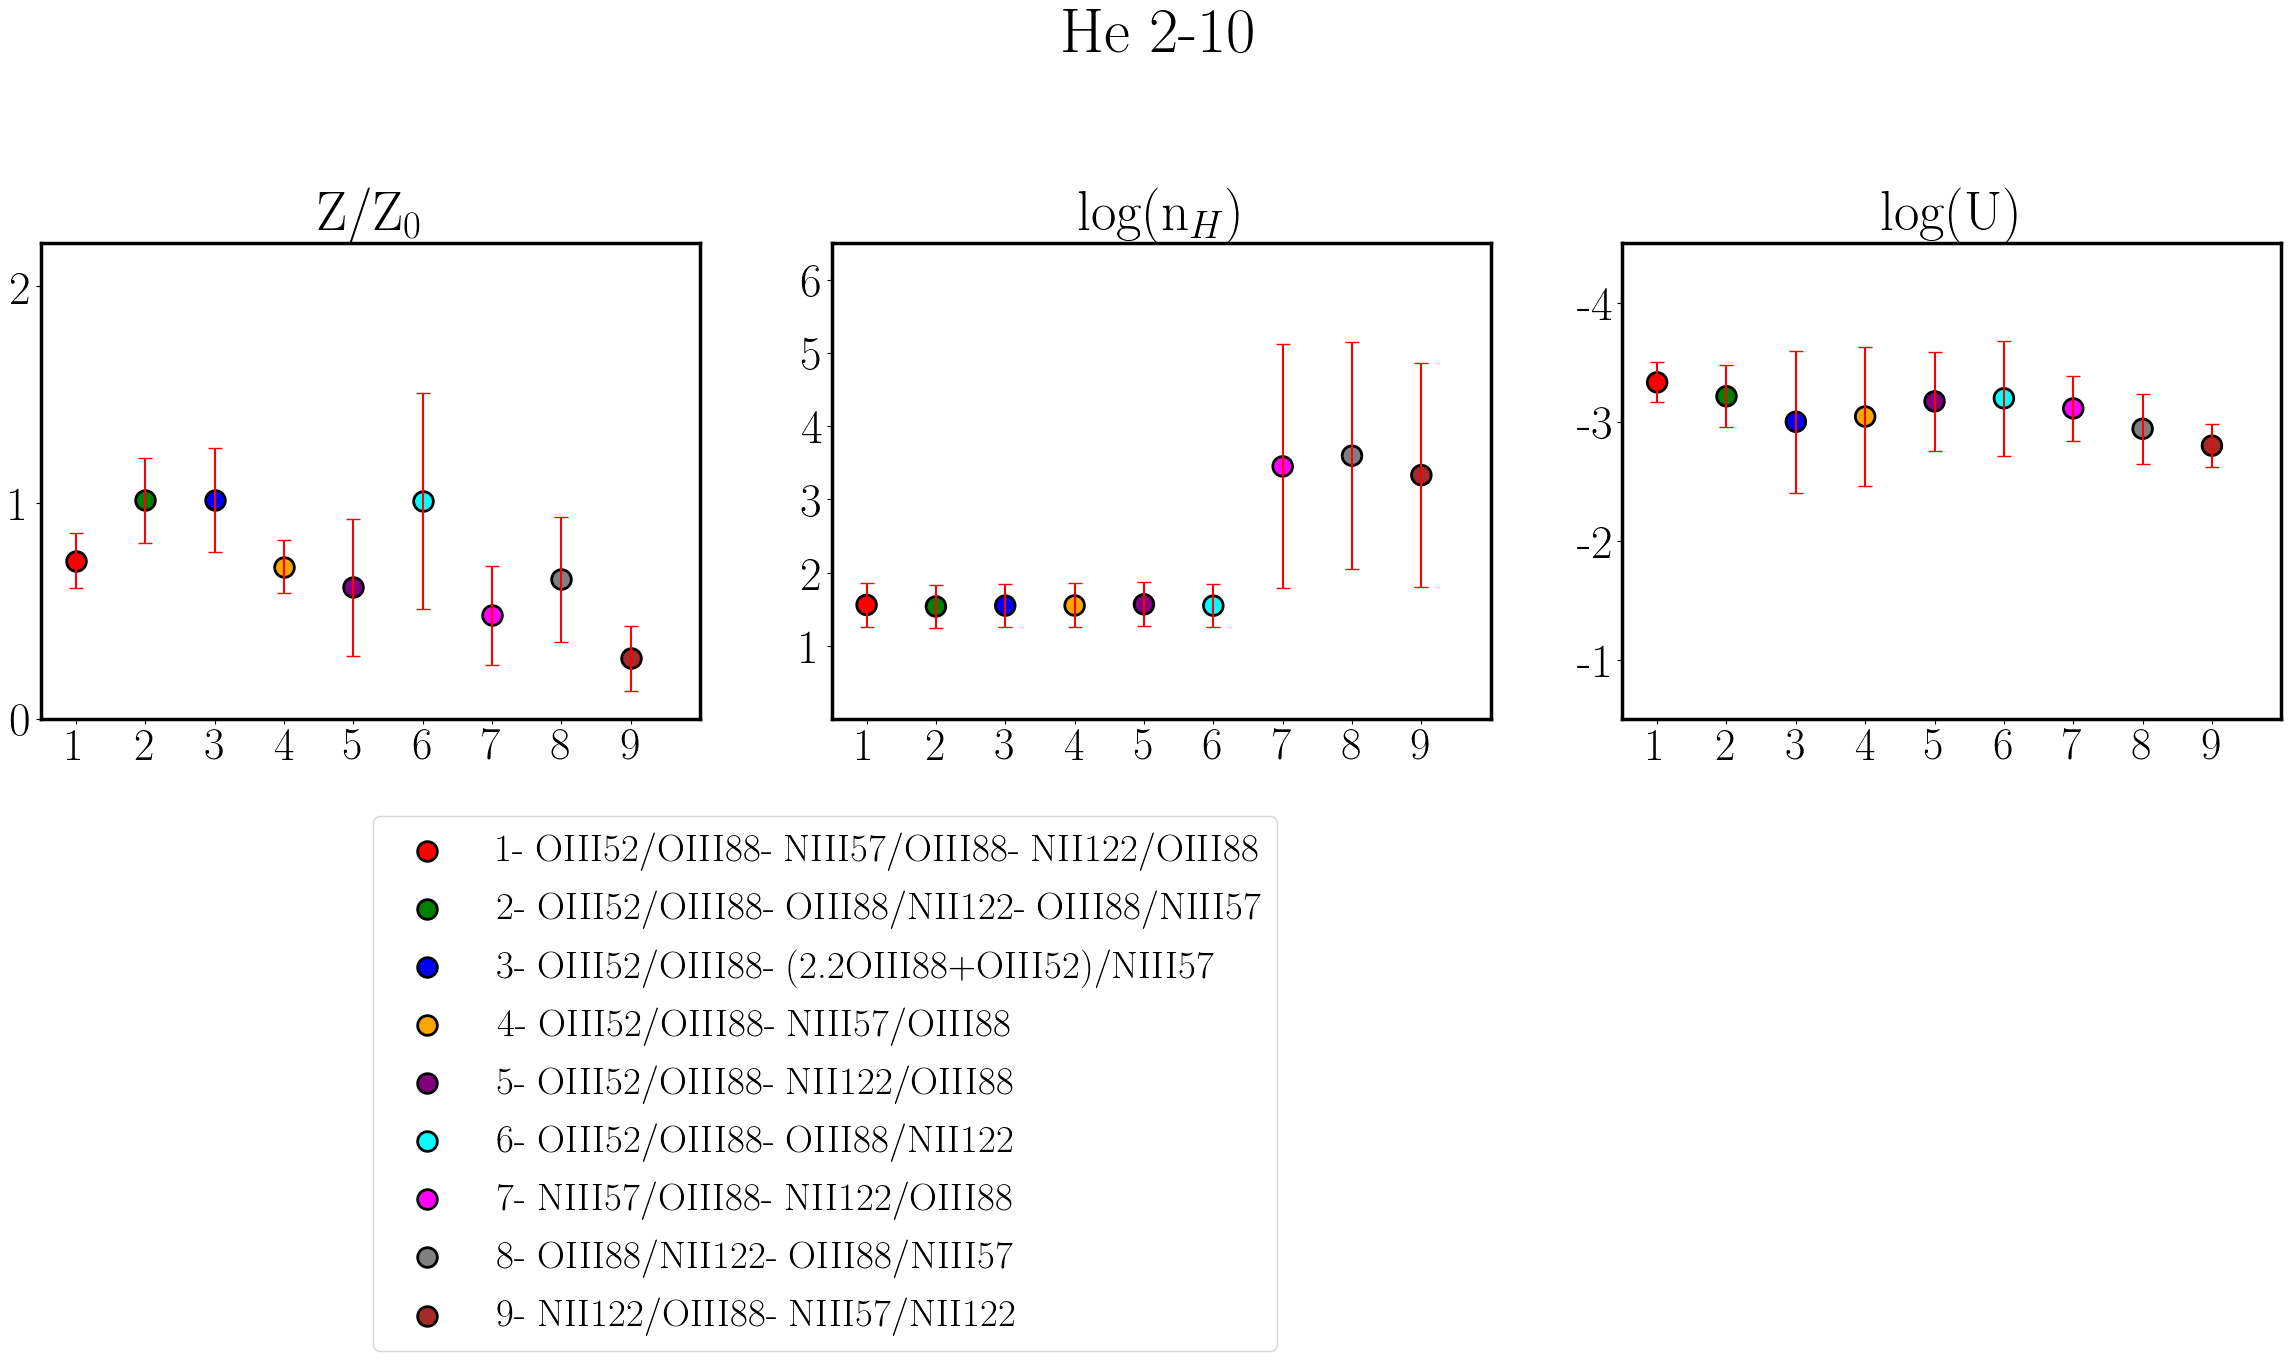

In [18]:
import matplotlib.pyplot as plt

import numpy as np

fig = plt.figure(figsize = (28,18))
plt.rc('text', usetex=True)
plt.rc("pdf", fonttype=3)
plt.rc('font',**{'family':'serif'})
plt.rc('xtick', labelsize=32) 
plt.rc('ytick', labelsize=34) 


fig.suptitle( 'He 2-10', fontsize=46)    
    

colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta','gray','brown']#, 'pink'
#np.random.rand(len(column_list)) # [0.601, 0.06,  0.901, 0.46 ]#
print(colors)

ax1 = plt.subplot(2,3,1) 
marks = ['o','o','o','o','o','o','o','o','o','o']
#for i,txt in enumerate(column_list):
for i in range(len(column_list)):
    
    plt.scatter(df_1.index[i], df_1['z_mn'][i] ,  marker =marks[i],  s =200, c = colors[i], edgecolors = 'black', 
                linewidths=2.0,   label = str(i+1)+column_list[i] )#txt )  

#plt.scatter(df_1.index, df_1['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['z_mn'], yerr=df_1['z_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,2.2)
plt.xlim(-0.5,9.0)
plt.title('Z/Z$_0$', fontsize=40)
#plt.ylabel('Z/Z$_0$', fontsize=34)
plt.yticks([0, 1, 2], ['0','1', '2', ])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])


ax2 =  plt.subplot(2,3,2)
plt.scatter(df_1.index, df_1['n_mn'] ,  marker ='o',  s =200, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['n_mn'], yerr=df_1['n_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,6.5)
plt.xlim(-0.5,9.0)
plt.title('log(n$_H$)', fontsize=40)
#plt.ylabel('n', fontsize=34)
plt.yticks([ 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6'])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])


ax3 = plt.subplot(2,3,3)
plt.scatter(df_1.index, df_1['u_mn'] ,  marker ='o',  s =200, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['u_mn'], yerr=df_1['u_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(-0.5,-4.5)
plt.xlim(-0.5,9.0)
plt.title('log(U)', fontsize=40)
#plt.ylabel('u', fontsize=34)
plt.yticks([ -1, -2, -3, -4,], ['-1', '-2', '-3', '-4'])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])

ax1.legend(bbox_to_anchor=(0.5, -0.2), loc='upper left', borderaxespad=0.05, fontsize= 28)
plt.subplots_adjust(top=0.85, bottom=0.3, left=0.1, right=0.90, hspace=0.08, wspace=0.20)


for axis in ['top','bottom','left','right']:
        ax1.spines[axis].set_linewidth(2.50) 
        ax2.spines[axis].set_linewidth(2.50) 
        ax3.spines[axis].set_linewidth(2.50)  
        

path = '/Users/admin/Scripts/GalaxyISM_0914/plots/' 
ArxName = path+'He-2-10-comparison_results-20230314.pdf'
        
saveFigure1 = True
if (saveFigure1):
            print (ArxName)
            plt.savefig(ArxName)


['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'gray', 'brown']
/Users/admin/Scripts/GalaxyISM_0914/plots/Hearo-03-comparison_results-20230314.pdf


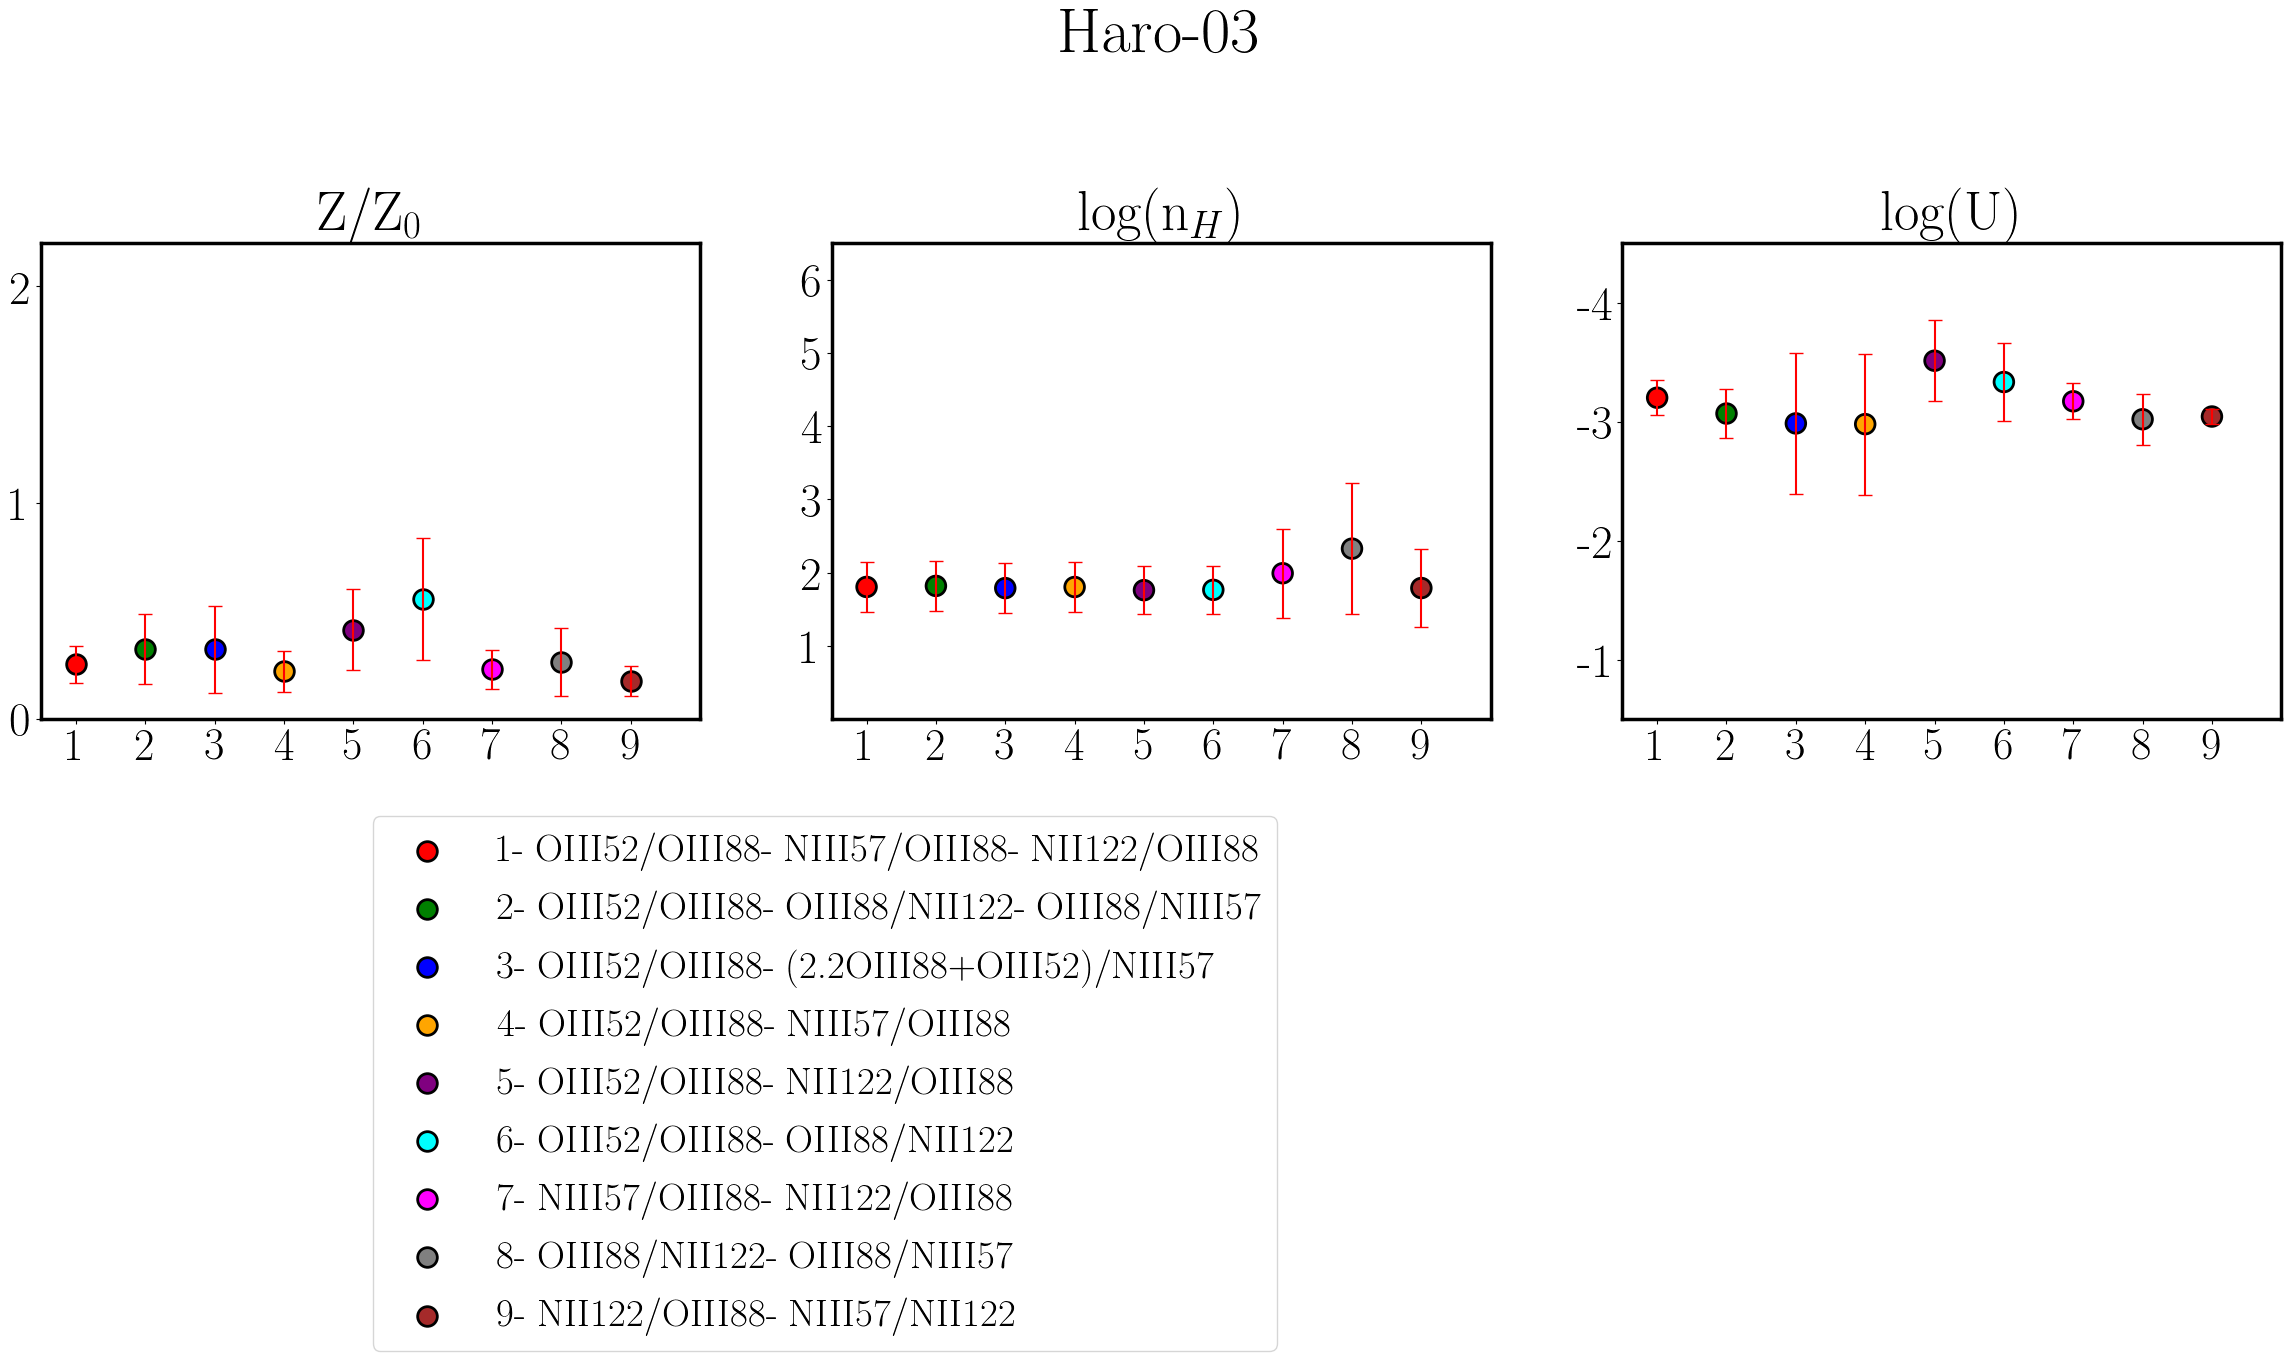

In [22]:
import matplotlib.pyplot as plt

import numpy as np

fig = plt.figure(figsize = (28,18))
plt.rc('text', usetex=True)
plt.rc("pdf", fonttype=3)
plt.rc('font',**{'family':'serif'})
plt.rc('xtick', labelsize=32) 
plt.rc('ytick', labelsize=34) 


fig.suptitle( 'Haro-03', fontsize=46)    
    

colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta','gray','brown']#, 'pink'
#np.random.rand(len(column_list)) # [0.601, 0.06,  0.901, 0.46 ]#
print(colors)

ax1 = plt.subplot(2,3,1) 
marks = ['o','o','o','o','o','o','o','o','o','o']
#for i,txt in enumerate(column_list):
for i in range(len(column_list)):
    
    plt.scatter(df_2.index[i], df_2['z_mn'][i] ,  marker =marks[i],  s =200, c = colors[i], edgecolors = 'black', 
                linewidths=2.0,   label = str(i+1)+column_list[i] )#txt )  

#plt.scatter(df_2.index, df_2['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_2.index, df_2['z_mn'], yerr=df_2['z_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,2.2)
plt.xlim(-0.5,9.0)
plt.title('Z/Z$_0$', fontsize=40)
#plt.ylabel('Z/Z$_0$', fontsize=34)
plt.yticks([0, 1, 2], ['0','1', '2', ])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])


ax2 =  plt.subplot(2,3,2)
plt.scatter(df_2.index, df_2['n_mn'] ,  marker ='o',  s =200, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_2.index, df_2['n_mn'], yerr=df_2['n_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,6.5)
plt.xlim(-0.5,9.0)
plt.title('log(n$_H$)', fontsize=40)
#plt.ylabel('n', fontsize=34)
plt.yticks([ 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6'])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])


ax3 = plt.subplot(2,3,3)
plt.scatter(df_2.index, df_2['u_mn'] ,  marker ='o',  s =200, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_2.index, df_2['u_mn'], yerr=df_2['u_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(-0.5,-4.5)
plt.xlim(-0.5,9.0)
plt.title('log(U)', fontsize=40)
#plt.ylabel('u', fontsize=34)
plt.yticks([ -1, -2, -3, -4,], ['-1', '-2', '-3', '-4'])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])

ax1.legend(bbox_to_anchor=(0.5, -0.2), loc='upper left', borderaxespad=0.05, fontsize= 28)
plt.subplots_adjust(top=0.85, bottom=0.3, left=0.1, right=0.90, hspace=0.08, wspace=0.20)


for axis in ['top','bottom','left','right']:
        ax1.spines[axis].set_linewidth(2.50) 
        ax2.spines[axis].set_linewidth(2.50) 
        ax3.spines[axis].set_linewidth(2.50)  
        

path = '/Users/admin/Scripts/GalaxyISM_0914/plots/' 
ArxName = path+'Hearo-03-comparison_results-20230314.pdf'
        
saveFigure1 = True
if (saveFigure1):
            print (ArxName)
            plt.savefig(ArxName)

['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta', 'gray', 'brown']
/Users/admin/Scripts/GalaxyISM_0914/plots/Hearo-10-comparison_results-20230314.pdf


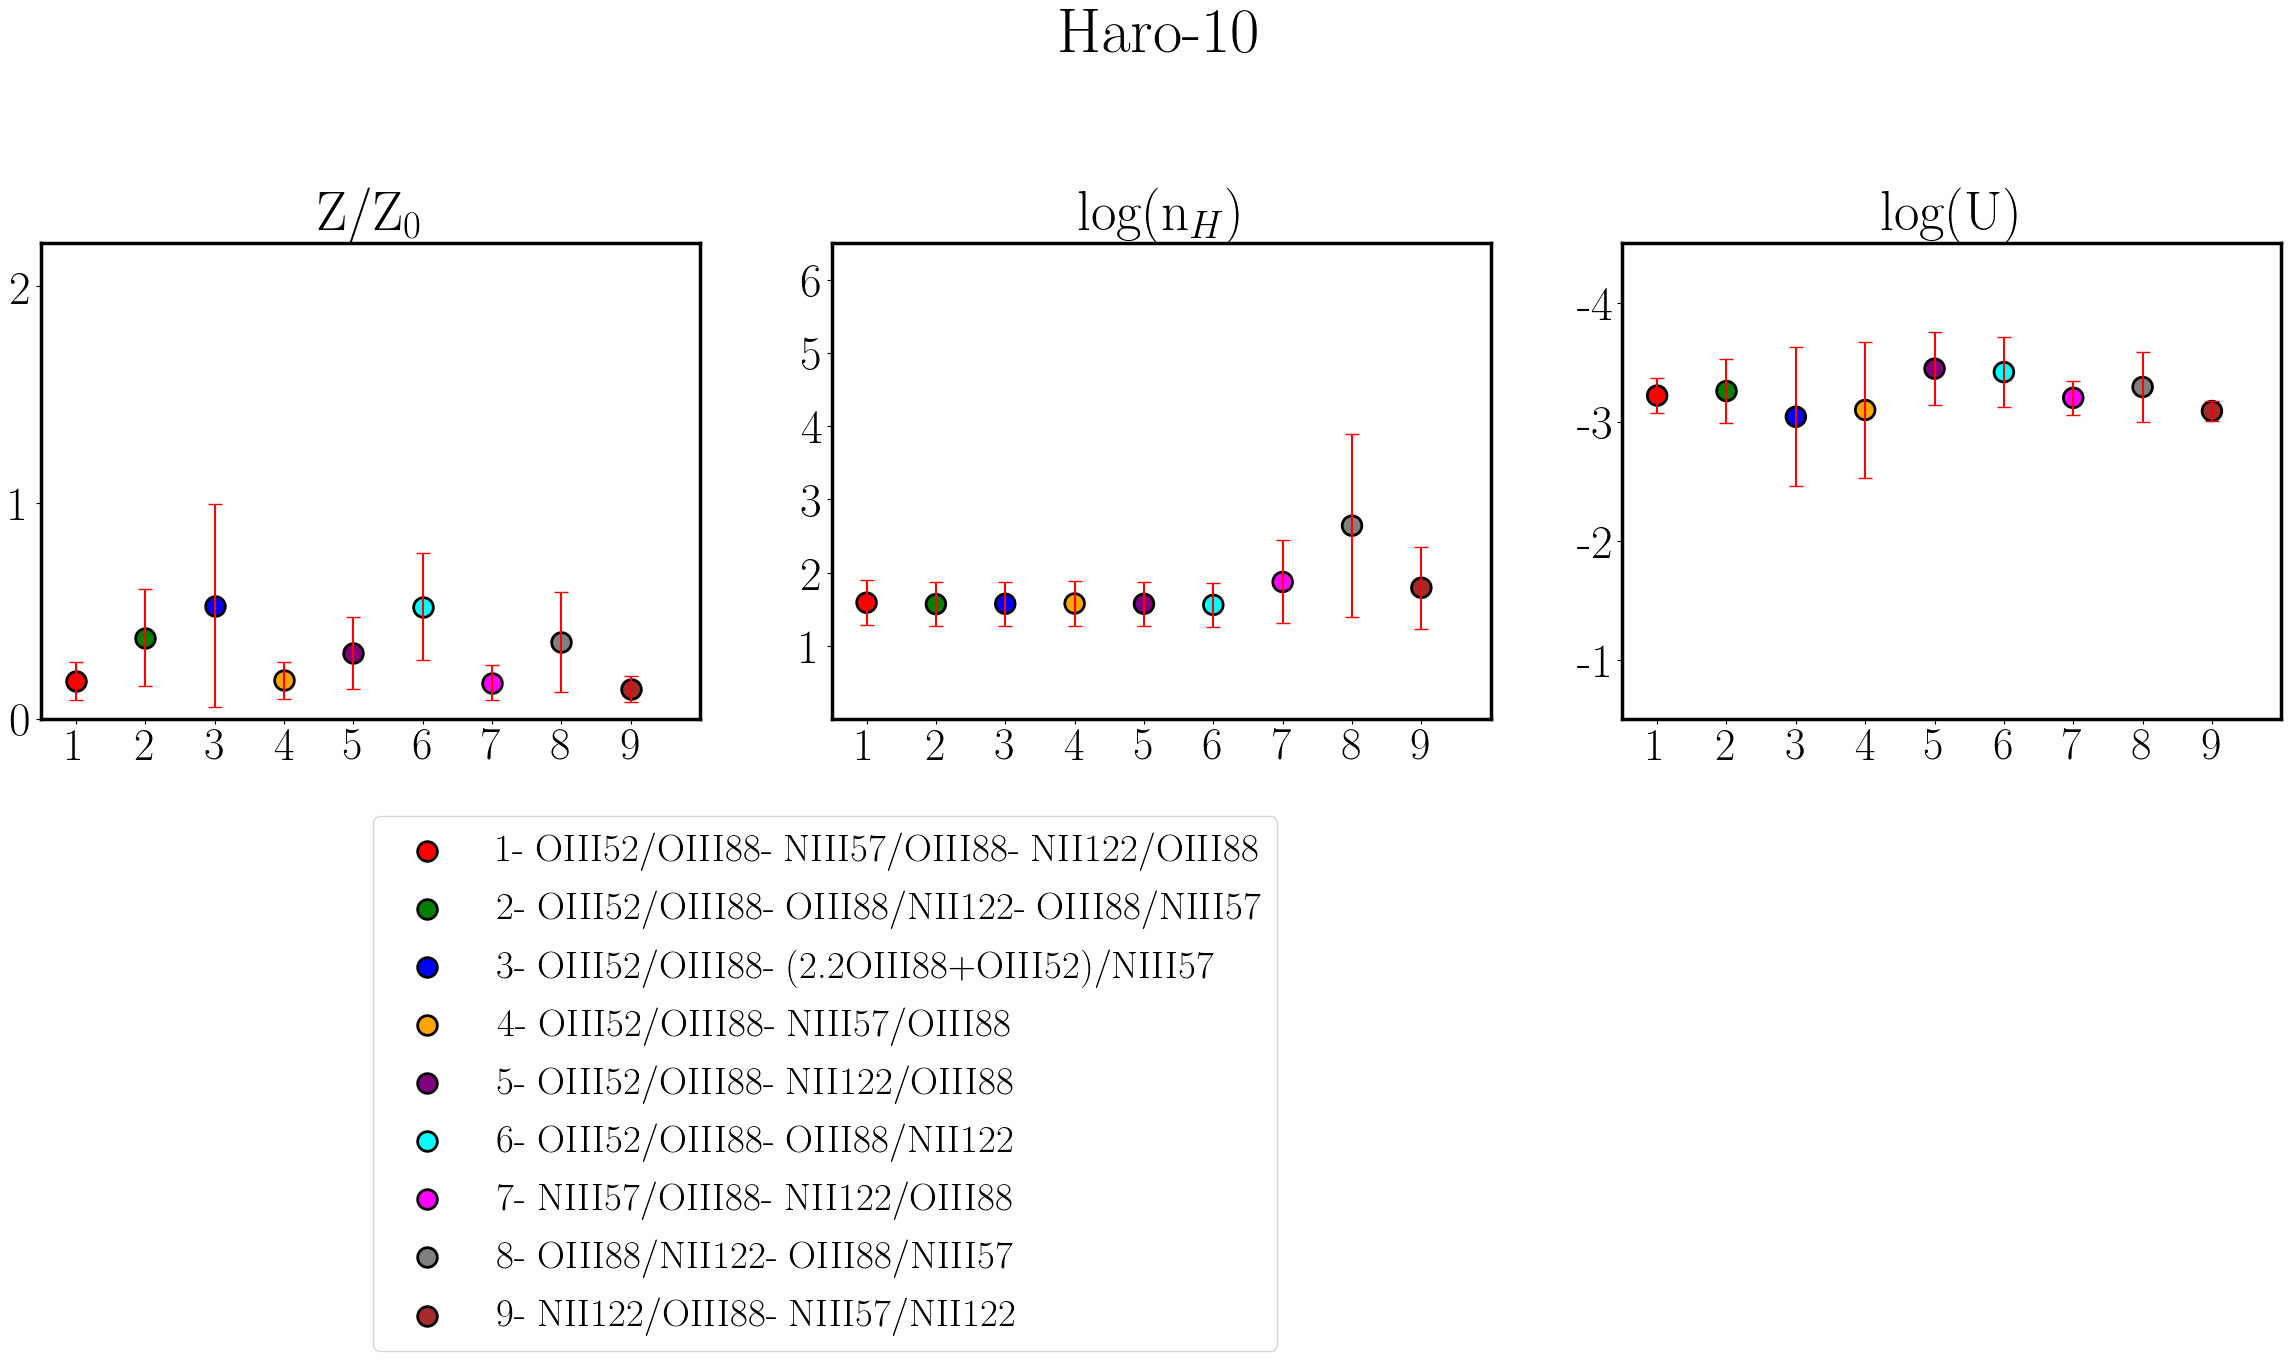

In [24]:
import matplotlib.pyplot as plt

import numpy as np

fig = plt.figure(figsize = (28,18))
plt.rc('text', usetex=True)
plt.rc("pdf", fonttype=3)
plt.rc('font',**{'family':'serif'})
plt.rc('xtick', labelsize=32) 
plt.rc('ytick', labelsize=34) 


fig.suptitle( 'Haro-10', fontsize=46)    
    

colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan', 'magenta','gray','brown']#, 'pink'
#np.random.rand(len(column_list)) # [0.601, 0.06,  0.901, 0.46 ]#
print(colors)

ax1 = plt.subplot(2,3,1) 
marks = ['o','o','o','o','o','o','o','o','o','o']
#for i,txt in enumerate(column_list):
for i in range(len(column_list)):
    
    plt.scatter(df_3.index[i], df_3['z_mn'][i] ,  marker =marks[i],  s =200, c = colors[i], edgecolors = 'black', 
                linewidths=2.0,   label = str(i+1)+column_list[i] )#txt )  

#plt.scatter(df_3.index, df_3['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_3.index, df_3['z_mn'], yerr=df_3['z_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,2.2)
plt.xlim(-0.5,9.0)
plt.title('Z/Z$_0$', fontsize=40)
#plt.ylabel('Z/Z$_0$', fontsize=34)
plt.yticks([0, 1, 2], ['0','1', '2', ])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])


ax2 =  plt.subplot(2,3,2)
plt.scatter(df_3.index, df_3['n_mn'] ,  marker ='o',  s =200, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_3.index, df_3['n_mn'], yerr=df_3['n_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,6.5)
plt.xlim(-0.5,9.0)
plt.title('log(n$_H$)', fontsize=40)
#plt.ylabel('n', fontsize=34)
plt.yticks([ 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6'])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])


ax3 = plt.subplot(2,3,3)
plt.scatter(df_3.index, df_3['u_mn'] ,  marker ='o',  s =200, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_3.index, df_3['u_mn'], yerr=df_3['u_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(-0.5,-4.5)
plt.xlim(-0.5,9.0)
plt.title('log(U)', fontsize=40)
#plt.ylabel('u', fontsize=34)
plt.yticks([ -1, -2, -3, -4,], ['-1', '-2', '-3', '-4'])
#plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['', '', '', '', '', '', '', '', ''])
plt.xticks([0, 1, 2, 3, 4, 5, 6,7,8], ['1', '2', '3', '4', '5', '6', '7','8','9'])

ax1.legend(bbox_to_anchor=(0.5, -0.2), loc='upper left', borderaxespad=0.05, fontsize= 28)
plt.subplots_adjust(top=0.85, bottom=0.3, left=0.1, right=0.90, hspace=0.08, wspace=0.20)


for axis in ['top','bottom','left','right']:
        ax1.spines[axis].set_linewidth(2.50) 
        ax2.spines[axis].set_linewidth(2.50) 
        ax3.spines[axis].set_linewidth(2.50)  
        

path = '/Users/admin/Scripts/GalaxyISM_0914/plots/' 
ArxName = path+'Hearo-10-comparison_results-20230314.pdf'
        
saveFigure1 = True
if (saveFigure1):
            print (ArxName)
            plt.savefig(ArxName)

In [ ]:

from matplotlib import cm

[cm(float(i)/(lgals )) for i in range(lgals)]

In [ ]:
import matplotlib.pyplot as plt

import numpy as np

fig = plt.figure(figsize = (28,18))
plt.rc('text', usetex=True)
plt.rc("pdf", fonttype=3)
plt.rc('font',**{'family':'serif'})
plt.rc('xtick', labelsize=32) 
plt.rc('ytick', labelsize=34) 



fig.suptitle( 'He 2-10', fontsize=46)
    
    

colors = np.random.rand(7) # [0.601, 0.06,  0.901, 0.46 ]#
print(colors)

ax1 = plt.subplot(2,3,1)
for i, txt in enumerate(column_list):
    plt.scatter(df_1.index, df_1['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0,
               label = txt )  
#plt.scatter(df_1.index, df_1['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['z_mn'], yerr=df_1['z_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,2.2)
plt.xlim(-0.5,7.0)
plt.title('Z/Z$_0$', fontsize=40)
#plt.ylabel('Z/Z$_0$', fontsize=34)
plt.yticks([0, 1, 2], ['0','1', '2', ])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['', '', '', '', '', '', ''])


ax2 =  plt.subplot(2,3,2)
plt.scatter(df_1.index, df_1['n_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['n_mn'], yerr=df_1['n_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,6.5)
plt.xlim(-0.5,7.0)
plt.title('log(n$_H$)', fontsize=40)
#plt.ylabel('n', fontsize=34)
plt.yticks([ 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['', '', '', '', '', '', ''])


ax3 = plt.subplot(2,3,3)
plt.scatter(df_1.index, df_1['u_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['u_mn'], yerr=df_1['u_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(-0.5,-4.5)
plt.xlim(-0.5,7.0)
plt.title('log(U)', fontsize=40)
#plt.ylabel('u', fontsize=34)
plt.yticks([ -1, -2, -3, -4,], ['-1', '-2', '-3', '-4'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['', '', '', '', '', '', ''])





ax4 = plt.subplot(2,3,4)
for i, txt in enumerate(column_list):
    plt.scatter(df_2.index, df_2['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0,
               label = txt ) 
#for i, txt in enumerate(column_list):
#    plt.scatter(txt, (df_2.index[i], df_2['z_mn'][i]), fontsize=14)
plt.errorbar(df_2.index, df_2['z_mn'], yerr=df_2['z_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,2.2)
plt.xlim(-0.5,7.0)
#plt.ylabel('Z/Z$_0$', fontsize=34) 
plt.yticks([0, 1, 2], ['0','1', '2', ])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6', '7'])


ax5 =  plt.subplot(2,3,5)
plt.scatter(df_2.index, df_2['n_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_2.index, df_2['n_mn'], yerr=df_2['n_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,6.5)
plt.xlim(-0.5,7.0)
plt.xlabel('Models combinations', fontsize=42)
#plt.ylabel('log(n$_0$)', fontsize=34)
plt.yticks([ 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6', '7'])



ax6 = plt.subplot(2,3,6)
plt.scatter(df_2.index, df_2['u_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0)  
plt.errorbar(df_2.index, df_2['u_mn'], yerr=df_2['u_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(-0.5,-4.5)
plt.xlim(-0.5,7.0)
#plt.ylabel('log(U)', fontsize=34)
plt.yticks([ -1, -2, -3, -4,], ['-1', '-2', '-3', '-4'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6', '7'])




ax4.legend(bbox_to_anchor=(0.5, -0.2), loc='upper left', borderaxespad=0.05, fontsize= 28)
plt.subplots_adjust(top=0.85, bottom=0.3, left=0.1, right=0.90, hspace=0.08, wspace=0.20)


for axis in ['top','bottom','left','right']:
        ax1.spines[axis].set_linewidth(2.50) 
        ax2.spines[axis].set_linewidth(2.50) 
        ax3.spines[axis].set_linewidth(2.50) 
        ax4.spines[axis].set_linewidth(2.50) 
        ax5.spines[axis].set_linewidth(2.50) 
        ax6.spines[axis].set_linewidth(2.50) 
        

path = '/Users/admin/Scripts/GalaxyISM_0914/plots/' 
ArxName = path+'He-2-10-comparison_results.pdf'
        
saveFigure1 = True
if (saveFigure1):
            print (ArxName)
            plt.savefig(ArxName)


In [ ]:
column_list = df_2['LinesRatiosUsed'].tolist()
column_list

In [ ]:

     
name     = 'Haro-03-'



file1 = 'UNZ_Haro-03-a_20240305.txt'
file2 = 'UNZ_Haro-03-b_20240305.txt'


df_1 = pd.read_csv(file1,  header = 0, engine='python') 
df_2 = pd.read_csv(file2,  header = 0, engine='python') 

df_1.columns



fig = plt.figure(figsize = (28,18))
plt.rc('text', usetex=True)
plt.rc("pdf", fonttype=3)
plt.rc('font',**{'family':'serif'})
plt.rc('xtick', labelsize=32) 
plt.rc('ytick', labelsize=34) 



fig.suptitle( 'Haro-03', fontsize=46)
    
    

colors = np.random.rand(7) # [0.601, 0.06,  0.901, 0.46 ]#
print(colors)

ax1 = plt.subplot(2,3,1)
plt.scatter(df_1.index, df_1['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['z_mn'], yerr=df_1['z_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,2.2)
plt.xlim(-0.5,7.0)
plt.title('Z/Z$_0$', fontsize=40)
#plt.ylabel('Z/Z$_0$', fontsize=34)
plt.yticks([0, 1, 2], ['0','1', '2', ])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['', '', '', '', '', '', ''])


ax2 =  plt.subplot(2,3,2)
plt.scatter(df_1.index, df_1['n_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['n_mn'], yerr=df_1['n_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,6.5)
plt.xlim(-0.5,7.0)
plt.title('log(n$_H$)', fontsize=40)
#plt.ylabel('n', fontsize=34)
plt.yticks([ 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['', '', '', '', '', '', ''])


ax3 = plt.subplot(2,3,3)
plt.scatter(df_1.index, df_1['u_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_1.index, df_1['u_mn'], yerr=df_1['u_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(-0.5,-4.5)
plt.xlim(-0.5,7.0)
plt.title('log(U)', fontsize=40)
#plt.ylabel('u', fontsize=34)
plt.yticks([ -1, -2, -3, -4,], ['-1', '-2', '-3', '-4'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['', '', '', '', '', '', ''])




column_list  = ['- OIII52/OIII88- NIII57/OIII88- NII122/OIII88',
 '- OIII52/OIII88- (2.2OIII88+OIII52)/NIII57',
 '- OIII52/OIII88- NIII57/NII122- (2.2OIII88+OIII52)/NIII57',
 '- NIII57/NII122- (2.2OIII88+OIII52)/NIII57',
 '- NIII57/NII122- (2.2OIII88+OIII52)/NIII57',
 '- OIII52/OIII88- OIII88/NII122- OIII88/NIII57',
 '- NIII57/NII122- OIII88/NII122- OIII88/NIII57']


ax4 = plt.subplot(2,3,4)
for i, txt in enumerate(column_list):
    plt.scatter(df_2.index, df_2['z_mn'] ,  marker ='o',  s =180, c = colors,   edgecolors = 'black', linewidths=2.0,
               label = txt)  
#for i, txt in enumerate(column_list):
#    plt.scatter(txt, (df_2.index[i], df_2['z_mn'][i]), fontsize=14)
plt.errorbar(df_2.index, df_2['z_mn'], yerr=df_2['z_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,2.2)
plt.xlim(-0.5,7.0)
#plt.ylabel('Z/Z$_0$', fontsize=34) 
plt.yticks([0, 1, 2], ['0','1', '2', ])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6', '7'])


ax5 =  plt.subplot(2,3,5)
plt.scatter(df_2.index, df_2['n_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0, label= '')  
plt.errorbar(df_2.index, df_2['n_mn'], yerr=df_2['n_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(0,6.5)
plt.xlim(-0.5,7.0)
plt.xlabel('Models combinations', fontsize=42)
#plt.ylabel('log(n$_0$)', fontsize=34)
plt.yticks([ 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6', '7'])



ax6 = plt.subplot(2,3,6)
plt.scatter(df_2.index, df_2['u_mn'] ,  marker ='o',  s =180, c = colors,  edgecolors = 'black', linewidths=2.0)  
plt.errorbar(df_2.index, df_2['u_mn'], yerr=df_2['u_unc'], fmt='none', ecolor='red', capsize=5)
plt.ylim(-0.5,-4.5)
plt.xlim(-0.5,7.0)
#plt.ylabel('log(U)', fontsize=34)
plt.yticks([ -1, -2, -3, -4,], ['-1', '-2', '-3', '-4'])
plt.xticks([0, 1, 2, 3, 4, 5, 6], ['1', '2', '3', '4', '5', '6', '7'])




ax4.legend(bbox_to_anchor=(0.5, -0.2), loc='upper left', borderaxespad=0.05, fontsize= 28)
plt.subplots_adjust(top=0.85, bottom=0.3, left=0.1, right=0.90, hspace=0.08, wspace=0.20)


for axis in ['top','bottom','left','right']:
        ax1.spines[axis].set_linewidth(2.50) 
        ax2.spines[axis].set_linewidth(2.50) 
        ax3.spines[axis].set_linewidth(2.50) 
        ax4.spines[axis].set_linewidth(2.50) 
        ax5.spines[axis].set_linewidth(2.50) 
        ax6.spines[axis].set_linewidth(2.50) 
        

path = '/Users/admin/Scripts/GalaxyISM_0914/plots/' 
ArxName = path+'Haro-03-comparison_results.pdf'
        
saveFigure1 = True
if (saveFigure1):
            print (ArxName)
            plt.savefig(ArxName)


In [ ]:
df_1

In [ ]:
df_2